# **GPU Run !**

Made By **LARBAOUI Yasmine Badr Elhouda**

# **Overall Goal of ML-SemReg**

This method enhances registration by leveraging semantic information (the “meaning” of points, example : “this point is part of a car, this is a tree”) and uses multi-level matching:

**- Local Semantic Signature (NSS) :**

* Normal registration tries to match points based on geometry or descriptors.

* ML-SemReg adds semantic context, so points with similar surroundings (like a cluster of points forming a car door) are more likely to match.

This reduces outliers in the matching.

**- Semantic Consistency Matching (SCM) :**

* Uses class information to improve matching.

* Only points of the same semantic class (e.g., “tree” with “tree”) are considered for matching.

* Helps filter out wrong matches between unrelated objects.

**- Guiding Semantic Structures (GSS) / Group Matching :**

* Groups keypoints into semantic-guided clusters and matches them as a group.

* Ensures that structured regions (like a car or a building) are matched consistently.

* Further reduces mismatches and improves robustness for complex scenes.

##**Setup ML-SemReg in Google Colab**

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
!nvidia-smi


Mon Dec 15 08:19:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!git clone https://github.com/Laka-3DV/ML-SemReg.git
%cd ML-SemReg


Cloning into 'ML-SemReg'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 94 (delta 6), reused 4 (delta 0), pack-reused 79 (from 1)
Receiving objects: 100% (94/94), 79.24 MiB | 33.12 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/ML-SemReg


In [4]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 147.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


# **The Pipeline of Demo**

- Load dataset (raw points + semantic labels + keypoints + descriptors).

- Compute local semantic signatures for keypoints : for a keypoint , it looks at nearby points and computes a signature that describes the local geometry and semantics ... (A)

- Second matching: Class-based / Semantic Consistency Matching (SCM) : Groups keypoints by semantic class and only matches points within the same group ... (B)

- Third matching: Guided Semantic Structures (GSS) / Group-based (BMR-SS) ... (C)

- Use GSS anchors to guide semantic matching.

- Compute correspondences using semantic + descriptor + GSS info.

- Evaluate correspondences (inlier number & ratio).

- Estimate transformation using SC2PCR.

- Visualize registration if requested.

- Evaluate final registration (rotation/translation error).

## **! This part of code not to run it ! Just to understand the code**

In [8]:
import torch
from tqdm import tqdm
import numpy as np
from easydict import EasyDict

'''
sets up everything the paper proposes: local signature computation (NSS),
grouping-based matching (SCM), semantic-guided matching (BMR-SS), and evaluation.

'''

# GroupingMatcher : groups keypoints by semantic category and matches only within groups : solves inter-class mismatching.
# query_local_signature (geometry based) builds local semantic neighborhoods of keypoints : computes local semantic signatures for keypoints (NSS step in the paper).
from MLSemReg.group_match import query_local_signature , GroupingMatcher

#constructs guiding semantic structures (GSS)
# get_anchor_pts_with_labels_outdoor: Selects guiding anchor points for the scene.
# grab_gss: Constructs Guiding Semantic Structures (GSS) around keypoints based on these anchors.
# maskmatcher_nn: Performs final mask-based matching using the group/structure information.
from MLSemReg.gss_constructor import grab_gss, get_anchor_pts_with_labels_outdoor

from MLSemReg.mask_matcher import maskmatcher_nn

#vis_pcr_pcd: visualize point clouds and registration results.
from utils_demo import vis_pcr_pcd, get_cmd_config, DataLoader

#evaluates evaluates registration metrics : inlier ratio, rotation and translation error, success.
from utils.evaluator import PCRResultEvaluator

#SC2PCR : a point cloud registration network used for the final transformation estimation.
from SC2PCR import SC2PCR

'''
Creates a registration evaluator :
used to evaluate the quality of correspondences and final registration.

'''
evaluator = PCRResultEvaluator(5, 0.6, 0.6)
# 5 → max distance threshold for inliers (in meters).
#0.6, 0.6 → thresholds for inlier ratio (source & target).


# sets up of multi-level semantic consistency parameters (local signature, anchor point selection, mask-based matching).
def get_config():
    config_lsig = EasyDict()
    config_lsig.radiu_local_sig = 0.8
    config_lsig.label_unuse = np.asarray([30, 31, 32, 252, 253, 254, 255, 256, 257, 258, 259])
    config_lsig.label_undefine = np.asarray([0])

    config_gss = EasyDict()
    config_gss.label_usefull = [16, 18, 80, 81, 10]
    config_gss.max_num_label = 8
    config_gss.N = 33
    config_gss.L = 1.5

    config_mask_match = EasyDict()
    config_mask_match.topx = 2

    return  config_lsig, config_gss, config_mask_match


def MLSemReg( # raw point clouds (downsampled).
             pts_src,
             pts_dst,
#semantic labels for points.
             label_src,
             label_dst,
#keypoints sampled from point clouds.
             kpts_src,
             kpts_dst,
#descriptors for keypoints.
             desc_src,
             desc_dst,
#ground truth transformation (for evaluation).
             trans_gt,
             config_lsig,
             config_gss,
             config_mask_match
             ):


'''NSS Local Semantic Signature : an array describing how the local neighborhood looks around each keypoint, including geometry and semantic labels.
- pts → raw 3D points of the cloud (N, 3)
- labels → semantic labels for each point (N,)
- keypoints → subset of points to compute signatures for (M, 3)
- radiu → radius to consider neighbors
why ? identify keypoints that are geometrically and semantically similar .
'''
    nss_src = query_local_signature(pts_src, label_src, kpts_src, radiu=config_lsig.radiu_local_sig)
    nss_dst = query_local_signature(pts_dst, label_dst, kpts_dst, radiu=config_lsig.radiu_local_sig)

'''
2. Semantic Consistency Matcher (SCM) :
match keypoints within semantic classes only
output : correspandance between keypoints src_idx , dst_idx
'''

    scmer = GroupingMatcher(nss_src, nss_dst, config_lsig=config_lsig)

'''
3. Build GSS (Guiding Semantic Structures)
step 1 : select anchor points and their labels and how many classes are present
step 2 :
'''

    ( # step 1
        is_use_gss,
        guidpost_pts_src, guidpost_label_src,
        guidpost_pts_dst, guidpost_label_dst, num_label_type
    ) = get_anchor_pts_with_labels_outdoor(pts_src, label_src, pts_dst, label_dst, **config_gss)

    if not is_use_gss:
        print("No BMRSS, skip it!")
        return

    # step 2 : structure information describing which points belong to which semantic group around a keypoint
    gss_src = grab_gss(kpts_src, guidpost_pts_src,
                        guidpost_label_src, **config_gss, num_label_type=num_label_type)
    gss_dst = grab_gss(kpts_dst, guidpost_pts_dst,
                        guidpost_label_dst, **config_gss, num_label_type=num_label_type)

    # step 3 : match : Uses semantic + descriptor + GSS info to compute keypoint correspondences.
    corres = scmer.run_match_based_on_gss(maskmatcher_nn, desc_src, desc_dst, gss_src, gss_dst, **config_mask_match)

    return corres #indices of matched keypoints.


def main():
    config_lsig, config_gss, config_mask_match = get_config()
    cmd_config = get_cmd_config()
    print(cmd_config)

    ds = DataLoader() # load the dataset
    # Iterates over point cloud pairs.
    for idx in tqdm(range(len(ds))):
        data = ds.get_item(idx)
        pts_src, label_src, kpts_src, desc_src, pts_dst, label_dst, kpts_dst, desc_dst, trans_gt = data
        evaluator.update_pair(pts_src, pts_dst, trans_gt=trans_gt)

        # Compute semantic correspondences.
        corres = MLSemReg(pts_src, pts_dst, label_src, label_dst, kpts_src, kpts_dst, desc_src, desc_dst, trans_gt, config_lsig, config_gss, config_mask_match)

        # Extract keypoints according to matches.
        kpts_src = kpts_src[corres[:, 0]]
        kpts_dst = kpts_dst[corres[:, 1]]

        # evaluation
        # IN : inlier matches
        # IR : Inlier Ratio
        IN, IR = evaluator.eval_corr(kpts_src, kpts_dst, is_print=False)

        # SC2PCR network predicts the rigid transformation between source and target.
        reger = SC2PCR()
        trans_pred = reger.forward(kpts_src, kpts_dst)

        # visualisation
        if cmd_config.is_vis:
            vis_pcr_pcd(pts_src, pts_dst, trans_pred)

        # evaluate the registration
        # rmse : root mean square error
        # rre : rotation error (degrees)
        # rte : translation error (meters)
        # is_success : success flag
        rmse, rre, rte, is_success = evaluator.eval_trans(trans=trans_pred)

        print(
            "\nInlier Number: {:.3f}".format(IN),
            "Inlier Ratio: {:.3f}%".format(IR * 100),
            "Rotation Error: {:.3f} degree".format(rre),
            "Translation Error: {:.3f} cm".format(rte * 100),
            "Is Successful: {}".format(is_success), sep="\n"
        )

if __name__=="__main__":
    main()

"""
python -m demo
python -m demo -is_vis
"""

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.12.12
[Taichi] Starting on arch=cuda


usage: colab_kernel_launcher.py [-h] [-is_vis]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-9c88eda6-ca5a-4474-852f-7999bebc49ad.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## **This is to run the code !**

In [9]:
!python demo.py


[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.12.12
[Taichi] Starting on arch=cuda
Namespace(is_vis=False)
  0% 0/40 [00:00<?, ?it/s]
Inlier Number: 1189.000
Inlier Ratio: 20.287%
Rotation Error: 0.289 degree
Translation Error: 12.285 cm
Is Successful: True
  2% 1/40 [00:05<03:53,  5.99s/it]
Inlier Number: 810.000
Inlier Ratio: 14.467%
Rotation Error: 0.256 degree
Translation Error: 12.201 cm
Is Successful: True
  5% 2/40 [00:10<03:11,  5.04s/it]
Inlier Number: 1256.000
Inlier Ratio: 20.871%
Rotation Error: 0.239 degree
Translation Error: 1.343 cm
Is Successful: True
  8% 3/40 [00:15<03:08,  5.09s/it]
Inlier Number: 1203.000
Inlier Ratio: 19.425%
Rotation Error: 0.241 degree
Translation Error: 11.422 cm
Is Successful: True
 10% 4/40 [00:20<02:54,  4.86s/it]
Inlier Number: 628.000
Inlier Ratio: 9.345%
Rotation Error: 0.469 degree
Translation Error: 3.354 cm
Is Successful: True
 12% 5/40 [00:24<02:44,  4.69s/it]
Inlier Number: 814.000
Inlier Ratio: 11.670%
Rotatio

#**Scenario-1: Semantic Label Noise**


##**Inject Semantic Noise into Labels**


This is the first weakness and Failure scenario

**Why this scenario?**

**ML-SemReg relies heavily on semantic labels:**

- GM (Group Matching) uses labels to eliminate cross-class matches

- MM (Mask Matching) uses local semantic context

If labels are wrong:

- Good matches get removed

- Wrong matches survive

- Registration drifts and fails

**How ?**

only modify labels before feeding to ML-SemReg : artificially "corrupt"

semantic labels

**Example:**

20% of car points → mislabeled as building

10% of road points → mislabeled as vegetation

In [10]:
import numpy as np
from MLSemReg.gss_constructor import grab_gss, get_anchor_pts_with_labels_outdoor
from MLSemReg.group_match import query_local_signature, GroupingMatcher
from MLSemReg.mask_matcher import maskmatcher_nn
from utils_demo import DataLoader
from utils.evaluator import PCRResultEvaluator
from SC2PCR import SC2PCR
from easydict import EasyDict

# === Configs from demo ===
def get_config():
    config_lsig = EasyDict()
    config_lsig.radiu_local_sig = 0.8
    config_lsig.label_unuse = np.asarray([30, 31, 32, 252, 253, 254, 255, 256, 257, 258, 259])
    config_lsig.label_undefine = np.asarray([0])

    config_gss = EasyDict()
    config_gss.label_usefull = [16, 18, 80, 81, 10]
    config_gss.max_num_label = 8
    config_gss.N = 33
    config_gss.L = 1.5

    config_mask_match = EasyDict()
    config_mask_match.topx = 2

    return config_lsig, config_gss, config_mask_match


# === Semantic noise ===
def corrupt_labels(labels, corruption_ratio=0.25, num_classes=20):
    labels_noisy = labels.copy()
    n = len(labels)
    # corrupt random points labels (idx : index of point in dataset)
    # choose n*corruption_ratio random position label from all the labels positions n
    idx = np.random.choice(n, int(n * corruption_ratio), replace=False)

    # choose randomly labels from 0 to num_possible_classes_of_labels
    # for the selected positions (len(idx))
    labels_noisy[idx] = np.random.randint(0, num_classes, size=len(idx))
    return labels_noisy


# === MLSemReg with noise ===
def MLSemReg_func(pts_src, pts_dst, label_src, label_dst,
                  kpts_src, kpts_dst, desc_src, desc_dst,
                  config_lsig, config_gss, config_mask_match):

    # Level 1: NSS
    nss_src = query_local_signature(pts_src, label_src, kpts_src, radiu=config_lsig.radiu_local_sig)
    nss_dst = query_local_signature(pts_dst, label_dst, kpts_dst, radiu=config_lsig.radiu_local_sig)

    scmer = GroupingMatcher(nss_src, nss_dst, config_lsig=config_lsig)

    # Level 2: GSS anchor extraction
    is_use_gss, guidpost_pts_src, guidpost_label_src, \
    guidpost_pts_dst, guidpost_label_dst, num_label_type = \
        get_anchor_pts_with_labels_outdoor(pts_src, label_src, pts_dst, label_dst, **config_gss)

    if not is_use_gss:
        return None

    # Compute GSS descriptor (BMR-SS)
    gss_src = grab_gss(kpts_src, guidpost_pts_src, guidpost_label_src,
                       **config_gss, num_label_type=num_label_type)
    gss_dst = grab_gss(kpts_dst, guidpost_pts_dst, guidpost_label_dst,
                       **config_gss, num_label_type=num_label_type)

    # Matching
    corres = scmer.run_match_based_on_gss(maskmatcher_nn,
                                          desc_src, desc_dst,
                                          gss_src, gss_dst,
                                          **config_mask_match)
    return corres


# === MAIN ===
def main():
    config_lsig, config_gss, config_mask_match = get_config()
    evaluator = PCRResultEvaluator(5, 0.6,0.6)

    ds = DataLoader()

    for idx in range(len(ds)):
        print("\n=========== Frame", idx, "============")

        pts_src, label_src, kpts_src, desc_src, \
        pts_dst, label_dst, kpts_dst, desc_dst, trans_gt = ds.get_item(idx)

        # Add semantic noise
        label_src_noisy = corrupt_labels(label_src, corruption_ratio=0.25)
        label_dst_noisy = corrupt_labels(label_dst, corruption_ratio=0.25)

        # Update evaluator
        evaluator.update_pair(pts_src, pts_dst, trans_gt=trans_gt)

        # Run MLSemReg
        correspondences = MLSemReg_func(
            pts_src, pts_dst,
            label_src_noisy, label_dst_noisy,
            kpts_src, kpts_dst, desc_src, desc_dst,
            config_lsig, config_gss, config_mask_match
        )

        if correspondences is None:
            print("No correspondences (GSS failure)")
            continue

        # Convert to numpy int indices
        corres = np.array(correspondences).astype(int)

        ksrc = kpts_src[corres[:, 0]]
        kdst = kpts_dst[corres[:, 1]]

        IN, IR = evaluator.eval_corr(ksrc, kdst)

        # Registration
        reg = SC2PCR()
        trans_pred = reg.forward(ksrc, kdst)

        # Evaluate transformation
        rmse, rre, rte, succ = evaluator.eval_trans(trans_pred)

        print(f"Inliers: {IN}, IR: {IR*100:.2f}%")
        print(f"Rotation Error: {rre:.3f} deg")
        print(f"Translation Error: {rte*100:.2f} cm")
        print("Success:", succ)


if __name__ == "__main__":
    main()



=========== Frame 0 ============
Inliers: 48, IR: 0.35%
Rotation Error: 179.773 deg
Translation Error: 1376.21 cm
Success: False

=========== Frame 1 ============
Inliers: 67, IR: 0.36%
Rotation Error: 131.856 deg
Translation Error: 1976.92 cm
Success: False

=========== Frame 2 ============
Inliers: 74, IR: 0.58%
Rotation Error: 0.500 deg
Translation Error: 24.89 cm
Success: True

=========== Frame 3 ============
Inliers: 366, IR: 2.22%
Rotation Error: 0.242 deg
Translation Error: 8.30 cm
Success: True

=========== Frame 4 ============
Inliers: 69, IR: 0.47%
Rotation Error: 59.486 deg
Translation Error: 1814.16 cm
Success: False

=========== Frame 5 ============
Inliers: 27, IR: 0.19%
Rotation Error: 173.807 deg
Translation Error: 2503.91 cm
Success: False

=========== Frame 6 ============
Inliers: 166, IR: 0.98%
Rotation Error: 4.736 deg
Translation Error: 1465.68 cm
Success: False

=========== Frame 7 ============
Inliers: 36, IR: 0.28%
Rotation Error: 8.194 deg
Translation Error: 

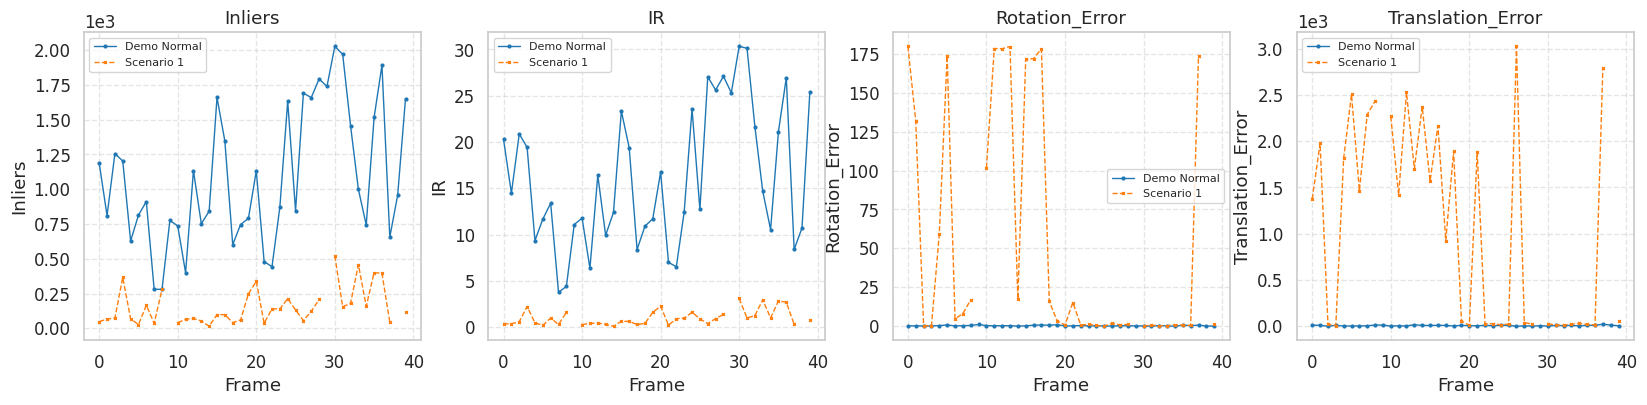

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Données Demo Normale
# --------------------------
demo_normal_data = {
    "Frame": list(range(40)),
    "Inliers": [1189,810,1256,1203,628,814,911,280,281,776,736,400,1134,752,842,1660,1346,602,746,791,
                1132,480,443,870,1633,845,1691,1659,1793,1739,2028,1970,1458,999,743,1516,1892,656,957,1652],
    "IR": [20.287,14.467,20.871,19.425,9.345,11.67,13.379,3.773,4.387,11.086,11.774,6.36,16.394,9.922,12.401,
           23.341,19.378,8.379,10.9,11.705,16.758,6.993,6.522,12.448,23.571,12.713,27.056,25.622,27.101,25.317,
           30.35,30.122,21.667,14.687,10.538,21.12,26.955,8.39,10.714,25.4],
    "Rotation_Error": [0.289,0.256,0.239,0.241,0.469,0.869,0.241,0.381,0.554,1.175,0.454,0.29,0.416,0.36,0.147,
                       0.321,0.699,0.816,0.72,0.996,0.196,0.253,0.51,0.263,0.335,0.236,0.161,0.361,0.387,0.253,
                       0.193,0.06,0.489,0.287,0.034,0.685,0.439,0.754,0.161,0.13],
    "Translation_Error": [12.285,12.201,1.343,11.422,3.354,4.291,3.962,6.32,14.555,13.84,3.564,5.97,4.84,18.202,9.973,
                          10.188,11.595,9.876,4.231,11.354,6.833,6.293,10.708,7.069,12.473,10.674,2.277,4.259,4.332,
                          5.875,3.81,9.646,7.474,10.218,5.167,10.882,11.579,23.56,14.01,6.572],
    "Success": [True]*40
}

df_normal = pd.DataFrame(demo_normal_data)

# --------------------------
# 2. Données Scenario 1
# --------------------------
scenario1_data = {
    "Frame": list(range(40)),
    "Inliers": [48,67,74,366,69,27,166,36,280,np.nan,40,65,71,53,15,99,98,41,60,249,
                338,36,140,139,214,132,56,122,208,np.nan,521,155,179,458,159,400,396,43,np.nan,120],
    "IR": [0.35,0.36,0.58,2.22,0.47,0.19,0.98,0.28,1.6,np.nan,0.27,0.4,0.44,0.29,0.09,0.63,0.61,0.28,0.4,1.59,
           2.26,0.21,0.91,0.96,1.6,0.89,0.37,0.92,1.38,np.nan,3.10,0.98,1.24,2.94,0.99,2.83,2.68,0.30,np.nan,0.76],
    "Rotation_Error": [179.773,131.856,0.5,0.242,59.486,173.807,4.736,8.194,16.989,np.nan,101.738,178.298,
                       178.179,179.604,17.387,171.319,171.82,178.059,16.08,3.545,0.774,15.279,0.893,1.174,0.555,
                       0.127,1.903,0.937,1.201,np.nan,0.17,0.791,0.331,0.42,1.029,0.659,0.582,173.81,np.nan,1.182],
    "Translation_Error": [1376.21,1976.92,24.89,8.3,1814.16,2503.91,1465.68,2287.44,2433.09,np.nan,2266.24,1418.89,
                          2526.55,1700.63,2372.85,1569.14,2166.12,926.06,1890.18,57.84,11.3,1879.99,28.53,29.03,17.06,
                          24.69,3024.74,39.95,24.63,np.nan,29.61,12.52,15.74,23.2,32.15,21.37,15.32,2788.7,np.nan,59.89],
    "Success": [False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,
                False,True,True,False,True,True,True,True,False,True,True,False,True,True,True,True,True,True,True,
                False,False,True]
}
"""
df_scenario1 = pd.DataFrame(scenario1_data)

# --------------------------
# 3. Tableau comparatif
# --------------------------
df_compare = df_normal.copy()
df_compare["Inliers_Scenario1"] = df_scenario1["Inliers"]
df_compare["IR_Scenario1"] = df_scenario1["IR"]
df_compare["Rotation_Error_Scenario1"] = df_scenario1["Rotation_Error"]
df_compare["Translation_Error_Scenario1"] = df_scenario1["Translation_Error"]
df_compare["Success_Scenario1"] = df_scenario1["Success"]

print("Tableau comparatif :")
print(df_compare)
"""
# --------------------------
# 4. Plots pour chaque métrique
# --------------------------
metrics = ["Inliers", "IR", "Rotation_Error", "Translation_Error"]
colors = ["#1f77b4", "#ff7f0e"]

fig, axes = plt.subplots(1, 4, figsize=(20,4))  # 1 ligne, 4 colonnes

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(df_compare["Frame"], df_compare[metric], marker='o', markersize=2, linestyle='-', linewidth=1, label="Demo Normal", color=colors[0])
    ax.plot(df_compare["Frame"], df_compare[f"{metric}_Scenario1"], marker='x', markersize=2, linestyle='--', linewidth=1, label="Scenario 1", color=colors[1])

    # notation scientifique si grandes valeurs
    if df_compare[metric].max() > 1000 or df_compare[f"{metric}_Scenario1"].max() > 1000:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    ax.set_xlabel("Frame")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    ax.set_title(metric)




#**SCENARIO 2 — Dynamic Objects**


**Goal:** To evaluate how ML-SemReg behaves when dynamic objects (cars, pedestrians, bicycles, etc.) are present in one scan but absent in the other, simulating real-world motion.

**Setup:**

Identify dynamic object classes: car, truck, pedestrian, bicycle.

Remove these objects from only one scan to create asymmetric semantic content.

Keep all other points unchanged.

**Expected effect:**

ML-SemReg relies on semantic consistency between scans.

Missing objects violate these assumptions:

\- Group Matching (GM) fails because points of a class exist only in one scan.

\- Mask Matching (MM) fails because the local semantic neighborhood is altered.

\- Some frames may fail registration entirely if no valid anchors are left.


In [11]:
import numpy as np
from easydict import EasyDict
from sklearn.neighbors import KDTree

from MLSemReg.gss_constructor import grab_gss, get_anchor_pts_with_labels_outdoor
from MLSemReg.group_match import query_local_signature, GroupingMatcher
from MLSemReg.mask_matcher import maskmatcher_nn
from utils_demo import DataLoader
from utils.evaluator import PCRResultEvaluator
from SC2PCR import SC2PCR


# ============================================================
# CONFIG
# ============================================================
def get_config():
    config_lsig = EasyDict()
    config_lsig.radiu_local_sig = 0.8
    config_lsig.label_unuse = np.asarray([30, 31, 32, 252, 253, 254, 255, 256, 257, 258, 259])
    config_lsig.label_undefine = np.asarray([0])

    config_gss = EasyDict()
    config_gss.label_usefull = [16, 18, 80, 81, 10]
    config_gss.max_num_label = 8
    config_gss.N = 33
    config_gss.L = 1.5

    config_mask_match = EasyDict()
    config_mask_match.topx = 2

    return config_lsig, config_gss, config_mask_match


# ============================================================
# MLSemReg main function
# ============================================================
def MLSemReg_func(pts_src, pts_dst, label_src, label_dst,
                  kpts_src, kpts_dst, desc_src, desc_dst,
                  config_lsig, config_gss, config_mask_match):

    nss_src = query_local_signature(pts_src, label_src, kpts_src, radiu=config_lsig.radiu_local_sig)
    nss_dst = query_local_signature(pts_dst, label_dst, kpts_dst, radiu=config_lsig.radiu_local_sig)

    scmer = GroupingMatcher(nss_src, nss_dst, config_lsig=config_lsig)

    is_use_gss, gsrc_pts, gsrc_lbl, gdst_pts, gdst_lbl, num_label_type = \
        get_anchor_pts_with_labels_outdoor(pts_src, label_src, pts_dst, label_dst, **config_gss)

    if not is_use_gss:
        return None

    gss_src = grab_gss(kpts_src, gsrc_pts, gsrc_lbl, **config_gss, num_label_type=num_label_type)
    gss_dst = grab_gss(kpts_dst, gdst_pts, gdst_lbl, **config_gss, num_label_type=num_label_type)

    corres = scmer.run_match_based_on_gss(
        maskmatcher_nn, desc_src, desc_dst, gss_src, gss_dst, **config_mask_match
    )
    return corres


# ============================================================
# SCENARIO 2 — Remove Dynamic Objects (Correct)
# ============================================================
def remove_dynamic_objects_correct(points, labels, kpts, desc,
                                   dynamic_classes = [10, 11, 13, 15, 18, 30, 31, 32]):
  # [10, 11, 13, 15, 18, 30, 31, 32] dynamic objects predefined in SemanticKITTI
  # # 10=car, 11=bicycle, 13=bus, 15=motorcycle, 18=truck, 30=person, 31=bicyclist, 32=motorcyclist

    # STEP 1: Find dynamic points
    # list of points but each record contain boolean for this points : dynamic / not
    dynamic_mask = np.isin(labels, dynamic_classes)

    # STEP 2: Build KDTree on ALL points
    # for an powerfull search : fast nearest-neighbor search.
    tree = KDTree(points)

    # STEP 3: For each keypoint → find nearest neighbor point to take her label
    # as the keypoints are not labeled , and tha fatest way to extract their label is by Nearst neighbor
    dist, idx = tree.query(kpts, k=1)
    nearest_point_labels = labels[idx[:, 0]]

    # STEP 4: Keep only keypoints that are NOT dynamic
    keep_kpts = ~np.isin(nearest_point_labels, dynamic_classes)

    # Filter keypoints + descriptors
    kpts_filtered = kpts[keep_kpts]
    desc_filtered = desc[keep_kpts]

    # Filter point cloud
    pts_filtered = points[~dynamic_mask]
    lbl_filtered = labels[~dynamic_mask]

    return pts_filtered, lbl_filtered, kpts_filtered, desc_filtered


# ============================================================
# MAIN
# ============================================================
def main():
    print("\n==== SCENARIO 2 (FIXED): Dynamic Objects Removed ====\n")

    config_lsig, config_gss, config_mask_match = get_config()
    ds = DataLoader()
    evaluator = PCRResultEvaluator(5, 0.6, 0.6)

    for idx in range(len(ds)):
        print(f"\n=========== Frame {idx} ===========")

        pts_src, lbl_src, kpts_src, desc_src, \
        pts_dst, lbl_dst, kpts_dst, desc_dst, T_gt = ds.get_item(idx)

        evaluator.update_pair(pts_src, pts_dst, trans_gt=T_gt)

        # REMOVE dynamic objects properly
        pts_src_dyn, lbl_src_dyn, kpts_src_dyn, desc_src_dyn = \
            remove_dynamic_objects_correct(pts_src, lbl_src, kpts_src, desc_src)

        # RUN MLSemReg
        corres = MLSemReg_func(
            pts_src_dyn, pts_dst,
            lbl_src_dyn, lbl_dst,
            kpts_src_dyn, kpts_dst,
            desc_src_dyn, desc_dst,
            config_lsig, config_gss, config_mask_match
        )

        if corres is None:
            print("GSS failed — no anchors")
            continue

        corres = np.array(corres).astype(int)
        src_m = kpts_src_dyn[corres[:, 0]]
        dst_m = kpts_dst[corres[:, 1]]

        IN, IR = evaluator.eval_corr(src_m, dst_m)

        reg = SC2PCR()
        T_pred = reg.forward(src_m, dst_m)

        rmse, rre, rte, succ = evaluator.eval_trans(T_pred)

        print(f"Inliers: {IN}, IR: {IR*100:.2f}%")
        print(f"RRE: {rre:.3f}°, RTE: {rte*100:.2f} cm")
        print("Success:", succ)


if __name__ == "__main__":
    main()



==== SCENARIO 2 (FIXED): Dynamic Objects Removed ====


=========== Frame 0 ===========
Inliers: 260, IR: 10.07%
RRE: 0.413°, RTE: 16.49 cm
Success: True

=========== Frame 1 ===========
Inliers: 116, IR: 4.47%
RRE: 0.473°, RTE: 18.71 cm
Success: True

=========== Frame 2 ===========
Inliers: 311, IR: 11.81%
RRE: 0.000°, RTE: 9.32 cm
Success: True

=========== Frame 3 ===========
Inliers: 229, IR: 11.40%
RRE: 0.147°, RTE: 16.03 cm
Success: True

=========== Frame 4 ===========
Inliers: 172, IR: 7.86%
RRE: 0.393°, RTE: 3.37 cm
Success: True

=========== Frame 5 ===========
GSS failed — no anchors

=========== Frame 6 ===========
GSS failed — no anchors

=========== Frame 7 ===========
GSS failed — no anchors

=========== Frame 8 ===========
There are no guidport.
GSS failed — no anchors

=========== Frame 9 ===========
There are no guidport.
GSS failed — no anchors

=========== Frame 10 ===========
Inliers: 93, IR: 7.31%
RRE: 0.602°, RTE: 22.18 cm
Success: True

=========== Frame 11 ==

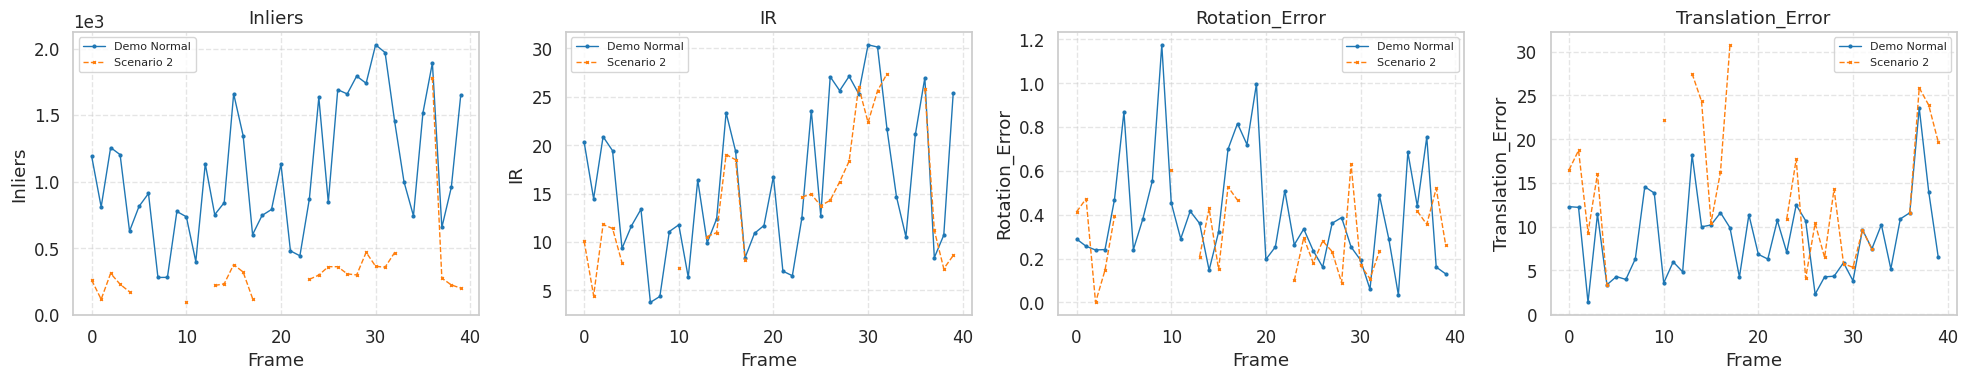

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Données Demo Normale
# --------------------------
demo_normal_data = {
    "Frame": list(range(40)),
    "Inliers": [1189,810,1256,1203,628,814,911,280,281,776,736,400,1134,752,842,1660,1346,602,746,791,
                1132,480,443,870,1633,845,1691,1659,1793,1739,2028,1970,1458,999,743,1516,1892,656,957,1652],
    "IR": [20.287,14.467,20.871,19.425,9.345,11.67,13.379,3.773,4.387,11.086,11.774,6.36,16.394,9.922,12.401,
           23.341,19.378,8.379,10.9,11.705,16.758,6.993,6.522,12.448,23.571,12.713,27.056,25.622,27.101,25.317,
           30.35,30.122,21.667,14.687,10.538,21.12,26.955,8.39,10.714,25.4],
    "Rotation_Error": [0.289,0.256,0.239,0.241,0.469,0.869,0.241,0.381,0.554,1.175,0.454,0.29,0.416,0.36,0.147,
                       0.321,0.699,0.816,0.72,0.996,0.196,0.253,0.51,0.263,0.335,0.236,0.161,0.361,0.387,0.253,
                       0.193,0.06,0.489,0.287,0.034,0.685,0.439,0.754,0.161,0.13],
    "Translation_Error": [12.285,12.201,1.343,11.422,3.354,4.291,3.962,6.32,14.555,13.84,3.564,5.97,4.84,18.202,9.973,
                          10.188,11.595,9.876,4.231,11.354,6.833,6.293,10.708,7.069,12.473,10.674,2.277,4.259,4.332,
                          5.875,3.81,9.646,7.474,10.218,5.167,10.882,11.579,23.56,14.01,6.572],
    "Success": [True]*40
}

df_normal = pd.DataFrame(demo_normal_data)

# --------------------------
# 2. Données Scenario 2
# --------------------------
scenario2_data = {
    "Frame": list(range(40)),
    "Inliers": [260,116,311,229,172,np.nan,np.nan,np.nan,np.nan,np.nan,93,np.nan,np.nan,220,232,377,321,122,
                np.nan,np.nan,np.nan,np.nan,np.nan,266,298,361,361,307,299,469,364,357,466,np.nan,np.nan,np.nan,1780,275,224,200],
    "IR": [10.07,4.47,11.81,11.40,7.86,np.nan,np.nan,np.nan,np.nan,np.nan,7.31,np.nan,np.nan,10.57,10.97,19.03,18.49,8.15,
           np.nan,np.nan,np.nan,np.nan,np.nan,14.65,14.93,13.75,14.30,16.22,18.34,26.04,22.34,25.61,27.36,np.nan,np.nan,np.nan,25.77,11.21,7.25,8.61],
    "Rotation_Error": [0.413,0.473,0.0,0.147,0.393,np.nan,np.nan,np.nan,np.nan,np.nan,0.602,np.nan,np.nan,0.209,0.429,0.150,0.527,0.466,
                       np.nan,np.nan,np.nan,np.nan,np.nan,0.100,0.295,0.180,0.280,0.232,0.090,0.632,0.169,0.108,0.233,np.nan,np.nan,np.nan,0.416,0.356,0.520,0.261],
    "Translation_Error": [16.49,18.71,9.32,16.03,3.37,np.nan,np.nan,np.nan,np.nan,np.nan,22.18,np.nan,np.nan,27.48,24.31,10.45,16.26,30.78,
                          np.nan,np.nan,np.nan,np.nan,np.nan,10.88,17.70,4.11,10.38,6.48,14.30,5.77,5.34,9.63,7.40,np.nan,np.nan,np.nan,11.59,25.86,23.89,19.72],
    "Success": [True]*40
}

df_scenario2 = pd.DataFrame(scenario2_data)

# --------------------------
# 3. Tableau comparatif
# --------------------------
df_compare2 = df_normal.copy()
df_compare2["Inliers_Scenario2"] = df_scenario2["Inliers"]
df_compare2["IR_Scenario2"] = df_scenario2["IR"]
df_compare2["Rotation_Error_Scenario2"] = df_scenario2["Rotation_Error"]
df_compare2["Translation_Error_Scenario2"] = df_scenario2["Translation_Error"]
df_compare2["Success_Scenario2"] = df_scenario2["Success"]

# --------------------------
# 4. Plots comparatif Demo Normal vs Scenario 2
# --------------------------
metrics = ["Inliers", "IR", "Rotation_Error", "Translation_Error"]
colors = ["#1f77b4", "#ff7f0e"]

fig, axes = plt.subplots(1, 4, figsize=(20,4))  # 1 ligne, 4 colonnes

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(df_compare2["Frame"], df_compare2[metric], marker='o', markersize=2, linestyle='-', linewidth=1, label="Demo Normal", color=colors[0])
    ax.plot(df_compare2["Frame"], df_compare2[f"{metric}_Scenario2"], marker='x', markersize=2, linestyle='--', linewidth=1, label="Scenario 2", color=colors[1])

    # notation scientifique si grandes valeurs
    if df_compare2[metric].max() > 1000 or df_compare2[f"{metric}_Scenario2"].max() > 1000:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    ax.set_xlabel("Frame")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    ax.set_title(metric)

plt.tight_layout()
plt.show()


#**SCENARIO 3 — Rolling Shutter / LiDAR Sweep Distortion**

**What happens in a real LiDAR scan?**

\- A LiDAR doesn’t capture the whole scene at once.

\- It rotates and scans line by line, taking ~100 ms for a full sweep.

\- Each point is measured at a slightly different instant.

\- If the vehicle or LiDAR moves even a little during this scan:

    - Each point is recorded according to the LiDAR’s pose at that instant.

    - Points are no longer perfectly aligned relative to each other.

**Why this causes problems ?**

To reconstruct an object or a scene, we rely on **local neighborhoods of points** (neighboring points close to each other).

**ML-SemReg** computes semantic signatures based on these neighborhoods.

If points are displaced due to LiDAR movement:

- Neighbors that should be part of the same local neighborhood are no longer in the right relative position.

- The structure of the object is slightly distorted, even if each individual point is correctly measured according to the LiDAR’s position at that moment.

- This introduces errors in local signatures and guiding structures → failure in semantic matching and registration.

**How simulates this ?**

\- All points (pts_src) and keypoints (kpts_src) of the source are slightly displaced.

\- X and Z coordinates stay the same.

\- Y is shifted according to X using a sinusoidal function.

The result simulates LiDAR motion during a scan, creating a small “bend” or distortion in the point cloud.


ML-SemReg thinks the points are still neighbors, but in reality, the geometry is slightly wrong.

**Key points :**

\- Points themselves are correctly measured at the LiDAR’s pose when the laser hit them.

\- The failure occurs because the LiDAR moved, so the relative positions of points are now incorrect.

\- Neighborhoods are corrupted, not individual points.

\- This causes **local semantic signatures (NSS) and guiding structures (GSS) to be incorrect** , leading to errors in semantic matching.

\- These errors are subtle and “masked” : the point cloud looks mostly correct,

but underlying relationships are wrong.


In [13]:
import numpy as np
from easydict import EasyDict

from MLSemReg.gss_constructor import grab_gss, get_anchor_pts_with_labels_outdoor
from MLSemReg.group_match import query_local_signature, GroupingMatcher
from MLSemReg.mask_matcher import maskmatcher_nn
from utils_demo import DataLoader
from utils.evaluator import PCRResultEvaluator
from SC2PCR import SC2PCR


# ============================================================
# CONFIG
# ============================================================
def get_config():
    config_lsig = EasyDict()
    config_lsig.radiu_local_sig = 0.8
    config_lsig.label_unuse = np.asarray([30, 31, 32, 252, 253, 254, 255, 256, 257, 258, 259])
    config_lsig.label_undefine = np.asarray([0])

    config_gss = EasyDict()
    config_gss.label_usefull = [16, 18, 80, 81, 10]
    config_gss.max_num_label = 8
    config_gss.N = 33
    config_gss.L = 1.5

    config_mask_match = EasyDict()
    config_mask_match.topx = 2

    return config_lsig, config_gss, config_mask_match


# ============================================================
# MLSemReg main function
# ============================================================
def MLSemReg_func(pts_src, pts_dst, label_src, label_dst,
                  kpts_src, kpts_dst, desc_src, desc_dst,
                  config_lsig, config_gss, config_mask_match):

    nss_src = query_local_signature(pts_src, label_src, kpts_src, radiu=config_lsig.radiu_local_sig)
    nss_dst = query_local_signature(pts_dst, label_dst, kpts_dst, radiu=config_lsig.radiu_local_sig)

    scmer = GroupingMatcher(nss_src, nss_dst, config_lsig=config_lsig)

    is_use_gss, gsrc_pts, gsrc_lbl, gdst_pts, gdst_lbl, num_label_type = \
        get_anchor_pts_with_labels_outdoor(pts_src, label_src, pts_dst, label_dst, **config_gss)

    if not is_use_gss:
        return None

    gss_src = grab_gss(kpts_src, gsrc_pts, gsrc_lbl, **config_gss, num_label_type=num_label_type)
    gss_dst = grab_gss(kpts_dst, gdst_pts, gdst_lbl, **config_gss, num_label_type=num_label_type)

    corres = scmer.run_match_based_on_gss(
        maskmatcher_nn, desc_src, desc_dst, gss_src, gss_dst, **config_mask_match
    )
    return corres
# scenario simulation
#intsensity = pour controller (maximiser / minimiser ) deplacement
'''
- keeping same z and  x-coordinate: pts2[:,0].

- modifying  y-coordinate : adding a small value that depends on the original x-coordinate (pts2[:,0]).


So each point is “shifted vertically” (in y) according to its horizontal position (x).

as result : points that were neighbors in the original object are no longer perfectly aligned in y,
 but their x is still correct. This is enough to break local neighborhood relationships, which in turn corrupts the local signatures used by ML-SemReg.
'''

def rolling_distort(pts, intensity=0.2):
    pts2 = pts.copy()
    pts2[:,1] += np.sin(pts2[:,0] * 10) * intensity
    return pts2


def main():
    print("\n==== SCENARIO 3: Rolling Shutter Distortion ====\n")

    config_lsig, config_gss, config_mask_match = get_config()
    ds = DataLoader()
    evaluator = PCRResultEvaluator(5, 0.6, 0.6)

    for idx in range(len(ds)):
        print(f"\n=========== Frame {idx} ===========")

        pts_src, lbl_src, kpts_src, desc_src, \
        pts_dst, lbl_dst, kpts_dst, desc_dst, T_gt = ds.get_item(idx)

        evaluator.update_pair(pts_src, pts_dst, trans_gt=T_gt)

        # Apply distortion only to source only
        pts_src_rs = rolling_distort(pts_src)
        kpts_src_rs = rolling_distort(kpts_src)

        corres = MLSemReg_func(
            pts_src_rs, pts_dst,
            lbl_src, lbl_dst,
            kpts_src_rs, kpts_dst,
            desc_src, desc_dst,
            config_lsig, config_gss, config_mask_match
        )

        if corres is None:
            print("GSS failed (distortion breaks groups)")
            continue

        corres = np.array(corres).astype(int)
        ksrc = kpts_src_rs[corres[:, 0]]
        kdst = kpts_dst[corres[:, 1]]

        IN, IR = evaluator.eval_corr(ksrc, kdst)

        reg = SC2PCR()
        T_pred = reg.forward(ksrc, kdst)

        rmse, rre, rte, succ = evaluator.eval_trans(T_pred)

        print(f"Inliers: {IN}, IR: {IR*100:.2f}%")
        print(f"RRE: {rre:.3f}°, RTE: {rte*100:.2f} cm")
        print("Success:", succ)


if __name__ == "__main__":
    main()



==== SCENARIO 3: Rolling Shutter Distortion ====


=========== Frame 0 ===========
Inliers: 1188, IR: 20.16%
RRE: 0.276°, RTE: 10.28 cm
Success: True

=========== Frame 1 ===========
Inliers: 792, IR: 14.06%
RRE: 0.248°, RTE: 12.09 cm
Success: True

=========== Frame 2 ===========
Inliers: 1199, IR: 19.78%
RRE: 0.218°, RTE: 1.55 cm
Success: True

=========== Frame 3 ===========
Inliers: 1191, IR: 19.13%
RRE: 0.246°, RTE: 12.19 cm
Success: True

=========== Frame 4 ===========
Inliers: 611, IR: 9.02%
RRE: 0.425°, RTE: 1.57 cm
Success: True

=========== Frame 5 ===========
Inliers: 793, IR: 11.22%
RRE: 0.987°, RTE: 3.42 cm
Success: True

=========== Frame 6 ===========
Inliers: 898, IR: 12.96%
RRE: 0.214°, RTE: 2.70 cm
Success: True

=========== Frame 7 ===========
Inliers: 268, IR: 3.57%
RRE: 0.380°, RTE: 6.31 cm
Success: True

=========== Frame 8 ===========
Inliers: 283, IR: 4.38%
RRE: 0.497°, RTE: 15.15 cm
Success: True

=========== Frame 9 ===========
Inliers: 742, IR: 10.60%
RRE: 

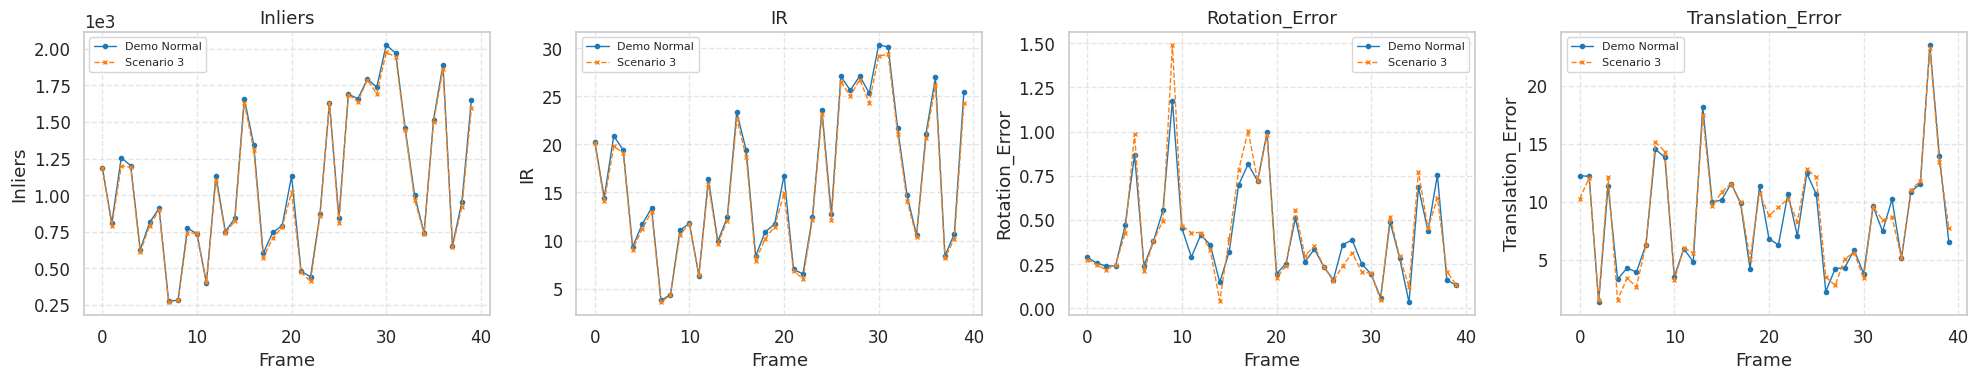

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Données Demo Normale
# --------------------------
demo_normal_data = {
    "Frame": list(range(40)),
    "Inliers": [1189,810,1256,1203,628,814,911,280,281,776,736,400,1134,752,842,1660,1346,602,746,791,
                1132,480,443,870,1633,845,1691,1659,1793,1739,2028,1970,1458,999,743,1516,1892,656,957,1652],
    "IR": [20.287,14.467,20.871,19.425,9.345,11.67,13.379,3.773,4.387,11.086,11.774,6.36,16.394,9.922,12.401,
           23.341,19.378,8.379,10.9,11.705,16.758,6.993,6.522,12.448,23.571,12.713,27.056,25.622,27.101,25.317,
           30.35,30.122,21.667,14.687,10.538,21.12,26.955,8.39,10.714,25.4],
    "Rotation_Error": [0.289,0.256,0.239,0.241,0.469,0.869,0.241,0.381,0.554,1.175,0.454,0.29,0.416,0.36,0.147,
                       0.321,0.699,0.816,0.72,0.996,0.196,0.253,0.51,0.263,0.335,0.236,0.161,0.361,0.387,0.253,
                       0.193,0.06,0.489,0.287,0.034,0.685,0.439,0.754,0.161,0.13],
    "Translation_Error": [12.285,12.201,1.343,11.422,3.354,4.291,3.962,6.32,14.555,13.84,3.564,5.97,4.84,18.202,9.973,
                          10.188,11.595,9.876,4.231,11.354,6.833,6.293,10.708,7.069,12.473,10.674,2.277,4.259,4.332,
                          5.875,3.81,9.646,7.474,10.218,5.167,10.882,11.579,23.56,14.01,6.572],
    "Success": [True]*40
}

df_normal = pd.DataFrame(demo_normal_data)

# --------------------------
# 2. Données Scenario 3
# --------------------------
scenario3_data = {
    "Frame": list(range(40)),
    "Inliers": [1188,792,1199,1191,611,793,898,268,283,742,739,404,1105,741,824,1631,1311,573,706,782,
                1019,473,412,859,1629,812,1688,1640,1789,1694,1976,1946,1444,969,738,1500,1862,649,920,1596],
    "IR": [20.16,14.06,19.78,19.13,9.02,11.22,12.96,3.57,4.38,10.60,11.75,6.38,15.83,9.68,12.07,22.63,18.72,7.91,10.18,11.45,
           14.90,6.86,6.00,12.17,23.15,12.12,26.50,25.02,26.73,24.31,29.17,29.37,21.11,14.12,10.38,20.66,26.13,8.18,10.21,24.29],
    "Rotation_Error": [0.276,0.248,0.218,0.246,0.425,0.987,0.214,0.380,0.497,1.491,0.468,0.429,0.428,0.329,0.043,0.392,0.782,1.006,0.720,0.981,
                       0.174,0.240,0.554,0.298,0.352,0.236,0.154,0.241,0.314,0.208,0.198,0.046,0.518,0.294,0.122,0.773,0.454,0.625,0.208,0.133],
    "Translation_Error": [10.28,12.09,1.55,12.19,1.57,3.42,2.70,6.31,15.15,14.35,3.27,6.05,5.57,17.47,9.63,10.85,11.59,9.99,5.07,10.75,
                          8.84,9.53,10.28,8.30,12.84,12.15,3.54,2.80,5.12,5.63,3.41,9.59,8.44,8.71,5.15,11.04,11.81,23.31,13.49,7.80],
    "Success": [True]*40
}

df_scenario3 = pd.DataFrame(scenario3_data)

# --------------------------
# 3. Tableau comparatif
# --------------------------
df_compare3 = df_normal.copy()
df_compare3["Inliers_Scenario3"] = df_scenario3["Inliers"]
df_compare3["IR_Scenario3"] = df_scenario3["IR"]
df_compare3["Rotation_Error_Scenario3"] = df_scenario3["Rotation_Error"]
df_compare3["Translation_Error_Scenario3"] = df_scenario3["Translation_Error"]
df_compare3["Success_Scenario3"] = df_scenario3["Success"]

# --------------------------
# 4. Plots comparatif Demo Normal vs Scenario 3
# --------------------------
metrics = ["Inliers", "IR", "Rotation_Error", "Translation_Error"]
colors = ["#1f77b4", "#ff7f0e"]  # Vert pour Scenario 3

fig, axes = plt.subplots(1, 4, figsize=(20,4))  # 1 ligne, 4 colonnes

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(df_compare3["Frame"], df_compare3[metric], marker='o', markersize=3, linestyle='-', linewidth=1, label="Demo Normal", color=colors[0])
    ax.plot(df_compare3["Frame"], df_compare3[f"{metric}_Scenario3"], marker='x', markersize=3, linestyle='--', linewidth=1, label="Scenario 3", color=colors[1])

    # notation scientifique si grandes valeurs
    if df_compare3[metric].max() > 1000 or df_compare3[f"{metric}_Scenario3"].max() > 1000:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    ax.set_xlabel("Frame")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    ax.set_title(metric)

plt.tight_layout()
plt.show()


#**SCENARIO 4 — Sensor Calibration Error**

**Context :**
- LiDAR sensors are usually mounted on vehicles or robots.

- Extrinsic calibration defines the exact position and orientation of the LiDAR relative to the vehicle.

**Problem**: Over time, small errors can appear due to:

\- Temperature changes → materials expand/contract

\- Vibrations from the vehicle

\- Loosening of the mount

Even tiny calibration errors mean that LiDAR points from different frames don’t perfectly align in the real world.

**Goal of this scenario**

Simulate the effect of calibration drift between scans.

**Idea**: apply a small rigid transformation (rotation + translation) to the

target scan, so that it is slightly misaligned relative to the source scan.

**How ?**

The function add_calib_noise :

\- Input: point cloud pts.

\- Rotation: rot_deg=2° around the Y-axis.

\- Translation: trans=0.1 m along X.

\- Returns a rigidly transformed point cloud.

**Effect :** the target point cloud is slightly rotated and shifted, simulating mis-calibration.


**Effect on ML-SemReg :**

- Neighborhood relationships between source and target are slightly wrong.

- **Guiding Semantic Structures (GSS)** may be corrupted because the keypoints of the target are slightly shifted.

- Matching may fail or be less accurate, because even if the source and target

see the same objects, they appear rotated/shifted relative to each other.



In [14]:
import numpy as np
import open3d as o3d
from easydict import EasyDict

from MLSemReg.gss_constructor import grab_gss, get_anchor_pts_with_labels_outdoor
from MLSemReg.group_match import query_local_signature, GroupingMatcher
from MLSemReg.mask_matcher import maskmatcher_nn
from utils_demo import DataLoader
from utils.evaluator import PCRResultEvaluator
from SC2PCR import SC2PCR


# ============================================================
# CONFIG
# ============================================================
def get_config():
    config_lsig = EasyDict()
    config_lsig.radiu_local_sig = 0.8
    config_lsig.label_unuse = np.asarray([30, 31, 32, 252, 253, 254, 255, 256, 257, 258, 259])
    config_lsig.label_undefine = np.asarray([0])

    config_gss = EasyDict()
    config_gss.label_usefull = [16, 18, 80, 81, 10]
    config_gss.max_num_label = 8
    config_gss.N = 33
    config_gss.L = 1.5

    config_mask_match = EasyDict()
    config_mask_match.topx = 2

    return config_lsig, config_gss, config_mask_match


# ============================================================
# MLSemReg main function
# ============================================================
def MLSemReg_func(pts_src, pts_dst, label_src, label_dst,
                  kpts_src, kpts_dst, desc_src, desc_dst,
                  config_lsig, config_gss, config_mask_match):

    nss_src = query_local_signature(pts_src, label_src, kpts_src, radiu=config_lsig.radiu_local_sig)
    nss_dst = query_local_signature(pts_dst, label_dst, kpts_dst, radiu=config_lsig.radiu_local_sig)

    scmer = GroupingMatcher(nss_src, nss_dst, config_lsig=config_lsig)

    is_use_gss, gsrc_pts, gsrc_lbl, gdst_pts, gdst_lbl, num_label_type = \
        get_anchor_pts_with_labels_outdoor(pts_src, label_src, pts_dst, label_dst, **config_gss)

    if not is_use_gss:
        return None

    gss_src = grab_gss(kpts_src, gsrc_pts, gsrc_lbl, **config_gss, num_label_type=num_label_type)
    gss_dst = grab_gss(kpts_dst, gdst_pts, gdst_lbl, **config_gss, num_label_type=num_label_type)

    corres = scmer.run_match_based_on_gss(
        maskmatcher_nn, desc_src, desc_dst, gss_src, gss_dst, **config_mask_match
    )
    return corres


def add_calib_noise(pts, rot_deg=2.0, trans=0.1):

# rot_deg : Rotation in degrees around the Y-axis (vertical axis).
# trans : Translation in meters along the X-axis.
    # 1. produce a rotation matrix based on our rot_degree (generated by the predefined function )
    # so we can apply it for our Points matrix (x,y,z)
    R = o3d.geometry.get_rotation_matrix_from_xyz(np.deg2rad([0, rot_deg, 0]))

    #2. we want to translate on x : x=trans else x,y=0
    T = np.array([trans, 0, 0]) # translation vector
    return pts @ R.T  + T #(.T transpose matrix not T translation vector)


def main():
    print("\n==== SCENARIO 4: Calibration Drift ====\n")

    config_lsig, config_gss, config_mask_match = get_config()
    ds = DataLoader()
    evaluator = PCRResultEvaluator(5, 0.6, 0.6)

    for idx in range(len(ds)):
        print(f"\n=========== Frame {idx} ===========")

        pts_src, lbl_src, kpts_src, desc_src, \
        pts_dst, lbl_dst, kpts_dst, desc_dst, T_gt = ds.get_item(idx)

        evaluator.update_pair(pts_src, pts_dst, trans_gt=T_gt)


        # Apply a simulated calibration drift to the target point cloud.
        # This moves all points of the scan as if the LiDAR had slightly changed its pose
        # (orientation and position) between scans. This simulates real-world extrinsic

        pts_dst_noise = add_calib_noise(pts_dst, rot_deg=2.0, trans=0.1)
        kpts_dst_noise = add_calib_noise(kpts_dst, rot_deg=2.0, trans=0.1)

        corres = MLSemReg_func(
            pts_src, pts_dst_noise,
            lbl_src, lbl_dst,
            kpts_src, kpts_dst_noise,
            desc_src, desc_dst,
            config_lsig, config_gss, config_mask_match
        )

        if corres is None:
            print("GSS failed due to calibration drift")
            continue

        corres = np.array(corres).astype(int)
        ksrc = kpts_src[corres[:, 0]]
        kdst = kpts_dst_noise[corres[:, 1]]

        IN, IR = evaluator.eval_corr(ksrc, kdst)

        reg = SC2PCR()
        T_pred = reg.forward(ksrc, kdst)

        rmse, rre, rte, succ = evaluator.eval_trans(T_pred)

        print(f"Inliers: {IN}, IR: {IR*100:.2f}%")
        print(f"RRE: {rre:.3f}°, RTE: {rte*100:.2f} cm")
        print("Success:", succ)


if __name__ == "__main__":
    main()



==== SCENARIO 4: Calibration Drift ====


=========== Frame 0 ===========
Inliers: 715, IR: 12.20%
RRE: 2.067°, RTE: 63.49 cm
Success: False

=========== Frame 1 ===========
Inliers: 431, IR: 7.70%
RRE: 2.030°, RTE: 66.35 cm
Success: False

=========== Frame 2 ===========
Inliers: 536, IR: 8.91%
RRE: 2.099°, RTE: 73.15 cm
Success: False

=========== Frame 3 ===========
Inliers: 630, IR: 10.17%
RRE: 2.202°, RTE: 65.18 cm
Success: False

=========== Frame 4 ===========
Inliers: 398, IR: 5.92%
RRE: 2.367°, RTE: 72.49 cm
Success: False

=========== Frame 5 ===========
Inliers: 305, IR: 4.37%
RRE: 2.433°, RTE: 73.77 cm
Success: False

=========== Frame 6 ===========
Inliers: 621, IR: 9.12%
RRE: 2.232°, RTE: 72.81 cm
Success: False

=========== Frame 7 ===========
Inliers: 80, IR: 1.08%
RRE: 1.649°, RTE: 66.96 cm
Success: False

=========== Frame 8 ===========
Inliers: 170, IR: 2.65%
RRE: 1.921°, RTE: 64.15 cm
Success: False

=========== Frame 9 ===========
Inliers: 446, IR: 6.37%
RRE: 1.77

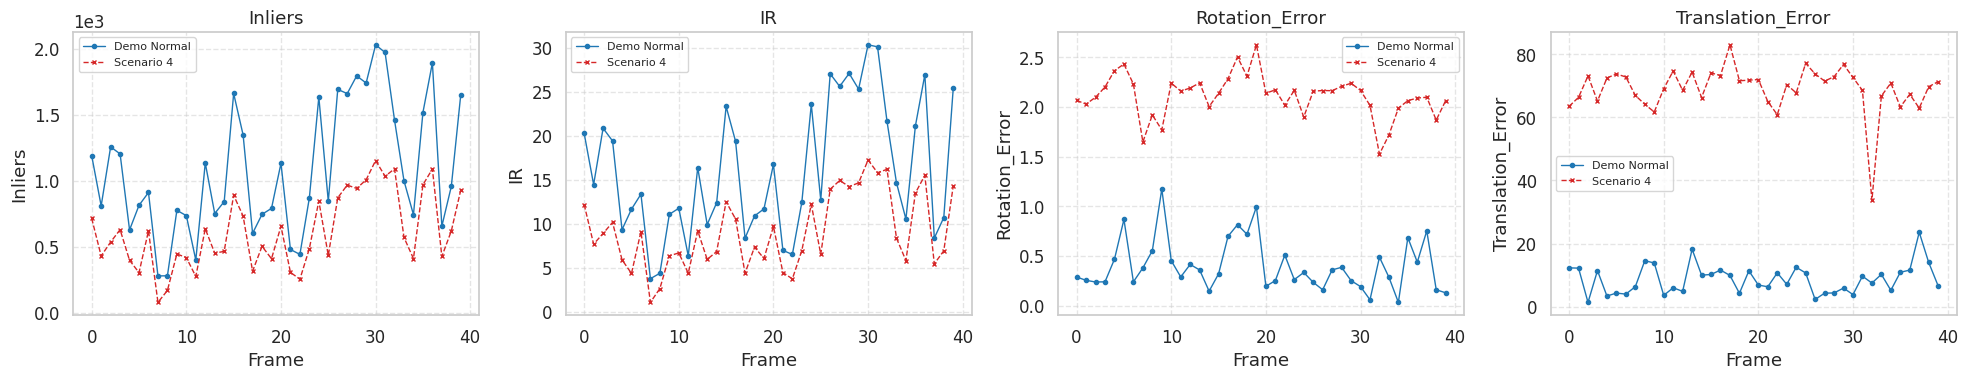

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Données Demo Normale
# --------------------------
demo_normal_data = {
    "Frame": list(range(40)),
    "Inliers": [1189,810,1256,1203,628,814,911,280,281,776,736,400,1134,752,842,1660,1346,602,746,791,
                1132,480,443,870,1633,845,1691,1659,1793,1739,2028,1970,1458,999,743,1516,1892,656,957,1652],
    "IR": [20.287,14.467,20.871,19.425,9.345,11.67,13.379,3.773,4.387,11.086,11.774,6.36,16.394,9.922,12.401,
           23.341,19.378,8.379,10.9,11.705,16.758,6.993,6.522,12.448,23.571,12.713,27.056,25.622,27.101,25.317,
           30.35,30.122,21.667,14.687,10.538,21.12,26.955,8.39,10.714,25.4],
    "Rotation_Error": [0.289,0.256,0.239,0.241,0.469,0.869,0.241,0.381,0.554,1.175,0.454,0.29,0.416,0.36,0.147,
                       0.321,0.699,0.816,0.72,0.996,0.196,0.253,0.51,0.263,0.335,0.236,0.161,0.361,0.387,0.253,
                       0.193,0.06,0.489,0.287,0.034,0.685,0.439,0.754,0.161,0.13],
    "Translation_Error": [12.285,12.201,1.343,11.422,3.354,4.291,3.962,6.32,14.555,13.84,3.564,5.97,4.84,18.202,9.973,
                          10.188,11.595,9.876,4.231,11.354,6.833,6.293,10.708,7.069,12.473,10.674,2.277,4.259,4.332,
                          5.875,3.81,9.646,7.474,10.218,5.167,10.882,11.579,23.56,14.01,6.572],
    "Success": [True]*40
}

df_normal = pd.DataFrame(demo_normal_data)

# --------------------------
# 2. Scenario 4: Calibration Drift
# --------------------------
scenario4_data = {
    "Frame": list(range(40)),
    "Inliers": [715,431,536,630,398,305,621,80,170,446,419,276,637,452,466,890,733,316,504,410,
                656,307,255,487,847,435,871,967,942,1007,1153,1034,1090,571,411,969,1089,427,620,930],
    "IR": [12.20,7.70,8.91,10.17,5.92,4.37,9.12,1.08,2.65,6.37,6.70,4.39,9.21,5.96,6.86,12.51,10.55,4.40,7.36,6.07,
           9.71,4.47,3.75,6.97,12.23,6.54,13.94,14.93,14.24,14.66,17.26,15.81,16.20,8.39,5.83,13.50,15.52,5.46,6.94,14.30],
    "Rotation_Error": [2.067,2.030,2.099,2.202,2.367,2.433,2.232,1.649,1.921,1.771,2.241,2.161,2.192,2.244,2.005,2.139,2.286,2.504,2.311,2.627,
                       2.139,2.174,2.019,2.169,1.900,2.160,2.167,2.165,2.209,2.240,2.168,2.017,1.527,1.719,1.989,2.065,2.091,2.099,1.869,2.066],
    "Translation_Error": [63.49,66.35,73.15,65.18,72.49,73.77,72.81,66.96,64.15,61.71,69.09,74.72,68.57,74.37,66.30,74.13,73.25,83.01,71.61,71.80,
                          71.99,65.03,60.85,70.39,67.76,77.14,73.78,71.51,72.89,76.79,72.65,68.55,33.71,66.79,70.89,63.32,67.31,62.93,69.73,71.33],
    "Success": [False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,
                False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False]
}

df_scenario4 = pd.DataFrame(scenario4_data)

# --------------------------
# 2. Comparatif Demo Normal vs Scenario 4
# --------------------------
df_compare4 = df_normal.copy()
df_compare4["Inliers_Scenario4"] = df_scenario4["Inliers"]
df_compare4["IR_Scenario4"] = df_scenario4["IR"]
df_compare4["Rotation_Error_Scenario4"] = df_scenario4["Rotation_Error"]
df_compare4["Translation_Error_Scenario4"] = df_scenario4["Translation_Error"]
df_compare4["Success_Scenario4"] = df_scenario4["Success"]

# --------------------------
# 3. Plots comparatif Demo Normal vs Scenario 4
# --------------------------
metrics = ["Inliers", "IR", "Rotation_Error", "Translation_Error"]
colors = ["#1f77b4", "#d62728"]  # Rouge pour Scenario 4

fig, axes = plt.subplots(1, 4, figsize=(20,4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(df_compare4["Frame"], df_compare4[metric], marker='o', markersize=3, linestyle='-', linewidth=1, label="Demo Normal", color=colors[0])
    ax.plot(df_compare4["Frame"], df_compare4[f"{metric}_Scenario4"], marker='x', markersize=3, linestyle='--', linewidth=1, label="Scenario 4", color=colors[1])

    # notation scientifique si grandes valeurs
    if df_compare4[metric].max() > 1000 or df_compare4[f"{metric}_Scenario4"].max() > 1000:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    ax.set_xlabel("Frame")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    ax.set_title(metric)

plt.tight_layout()
plt.show()
